# Linguistic Forensic Audit: NER & POS Drift

**Ship of Theseus : Computational Forensics**  
CS 6120 · Spring 2026 · Northeastern University

This notebook measures how POS-tag distributions (style) and named entities (content) erode across paraphrasing iterations, directly informing **RQ1: Style vs. Content Decay**.

---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import (
    ALL_DATASETS, VERSION_TO_COL, DATA_PROCESSED,
    SPACY_MODEL, FIGURES_DIR, EXPERIMENTS_DIR,
)
from src.data.load_data import load_paired_t1
from src.features.pos import UPOS_TAGS, extract_pos_vectors
from src.utils.metrics import batch_cosine_similarity

TEXT_COLS = list(VERSION_TO_COL.values())

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "eda").mkdir(exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Datasets     : {ALL_DATASETS}")
print(f"UPOS tags    : {len(UPOS_TAGS)} tags")

Project root : C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP
Datasets     : ['cmv', 'eli5', 'sci_gen', 'tldr', 'wp', 'xsum', 'yelp']
UPOS tags    : 17 tags


---
## Task 1 : Data Processing & Version Alignment

**Goal:** Pair the original (T0) text of each article with its T1 paraphrased versions across multiple paraphrasers, using `(key, source, dataset)` as the composite identifier.

| Output column | Version string | Paraphraser |
|---|---|---|
| `text_T0` | `original` | : |
| `text_chatgpt` | `chatgpt` | ChatGPT |
| `text_dipper_high` | `dipper(high)` | Dipper (High) |
| `text_dipper_low` | `dipper(low)` | Dipper (Low) |
| `text_pegasus_slight` | `pegasus(slight)` | Pegasus (Slight) |
| `text_pegasus_full` | `pegasus(full)` | Pegasus (Full) |

Version parsing uses a regex that finds the shortest repeating base token : no naive underscore splitting.  
The `orignal` typo is normalised to `original`. See `src/utils/config.parse_version` for details.

In [2]:
paired = load_paired_t1(cache=True)

Loaded cached pivot: (19182, 9) from C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP\data\processed\paired_all.pkl


### 1c. Deliverable

Print `paired.shape`, display 2 rows per dataset (14 total), and confirm the `dataset` column and `text_dipper_low` column are present.

In [3]:
print(f"paired.shape = {paired.shape}")
print(f"\nColumns: {list(paired.columns)}")
print(f"\n'dataset' column present : {'dataset' in paired.columns}")
print(f"'text_dipper_low' present: {'text_dipper_low' in paired.columns}")

# 2 rows per dataset
sample = paired.groupby("dataset").head(2)
print(f"\nSample: 2 rows per dataset ({len(sample)} rows total)")

display_cols = ["key", "source", "dataset"] + TEXT_COLS
display_df = sample[display_cols].copy()
for col in TEXT_COLS:
    display_df[col] = display_df[col].apply(
        lambda x: x[:80] + "..." if isinstance(x, str) and len(x) > 80 else x
    )
display_df

paired.shape = (19182, 9)

Columns: ['key', 'source', 'dataset', 'text_T0', 'text_chatgpt', 'text_dipper_high', 'text_dipper_low', 'text_pegasus_full', 'text_pegasus_slight']

'dataset' column present : True
'text_dipper_low' present: True

Sample: 2 rows per dataset (14 rows total)


,key,source,dataset,text_T0,text_chatgpt,text_dipper_high,text_dipper_low,text_pegasus_slight,text_pegasus_full
0,cmv-1079,BigScience,cmv,Please note before reading: Please do not down...,Please be aware that I kindly request not to d...,A style of camouflaging the impossible became...,Please note before reading: Do not downvote m...,Please note before reading: Please do not down...,Please don't downvote my comments and replies ...
1,cmv-1079,Eleuther-AI,cmv,Please note before reading: Please do not down...,I kindly request that you refrain from downvot...,"Remember once again I say, downvoting is not ...",Please note before reading: Please do not dow...,Please don't downvote my comments and replies ...,Please don't downvote my comments and replies ...
1626,eli5-16706,BigScience,eli5,It's your body that is preparing to fight for ...,"When faced with a threatening situation, your ...",They had gone to watch—a perilous walk—from L...,Because your brain perceives it as a threat. ...,It's your body that is preparing to fight for ...,"If you see something threatening, your body is..."
1627,eli5-16706,Eleuther-AI,eli5,It's your body that is preparing to fight for ...,When your brain perceives something threatenin...,You must have foreseen some dreadful monster ...,Because your brain takes it as a threat. It i...,It's your body that is preparing to fight for ...,"If you see something threatening, your body is..."
4786,sci_gen-1744,BigScience,sci_gen,"In this article, we investigate the transient ...",This article explores the behavior of packetsb...,These were three years of great difficulty. T...,"In this article, we investigate the transient...","In this article, we investigate the transient ...",Transient behavior of packetsbits traversing a...
4787,sci_gen-1744,Human,sci_gen,"In this article, we investigate whispered-to n...",This article examines a method for converting ...,Gulathy blew two pitcherfuls of tea for himse...,"In this article, we investigate a whisper-to-...","In this article, we investigate whispered-to n...",We investigated whispered-to natural-speech co...
7583,tldr-2826,BigScience,tldr,Tensorflow Privacy implements Tensorflow optim...,Tensorflow Privacy is a library that enables t...,The next morning we went down to the little t...,Contribution to the research field: TensorFlo...,Machine learning models with differential priv...,Machine learning models with differential priv...
7584,tldr-2826,Eleuther-AI,tldr,Tensorflow Privacy implements Tensorflow optim...,Tensorflow Privacy provides Tensorflow optimiz...,There was a chance of seeing Amsden's line in...,TensorFlow privacy is an implementation of Te...,Machine learning models with differential priv...,Machine learning models with differential priv...
10027,wp-1198,BigScience,wp,"""and those are the terms. I'm sorry."" The Athe...","""Those are the terms, and I apologize,"" said t...",Atheism pressed her with even greater persuas...,"The atheist, a young female hipster in thick-...","""and those are the terms. I'm sorry. The Athei...","Those are the terms. I'm sorry. The Atheist, a..."
10028,wp-1198,Eleuther-AI,wp,"""and those are the terms. I'm sorry."" The Athe...","""Those are the conditions, and I apologize."" T...","Ah, that’s really too bad!” “Well, that’s abo...","The Atheist, a young female hipster in thick-...","""and those are the terms. I'm sorry. The Athei...","Those are the terms. I'm sorry. The Atheist, a..."


In [4]:
print("Articles per dataset:")
print(paired.groupby("dataset").size().to_string())
print(f"\nTotal articles: {len(paired):,}")
print(f"Unique sources: {sorted(paired['source'].unique())}")

Articles per dataset:
dataset
cmv        1621
eli5       3145
sci_gen    2763
tldr       2421
wp         2725
xsum       3197
yelp       3310

Total articles: 19,182
Unique sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']


---

*To reload on subsequent runs, `load_paired_t1(cache=True)` reads from pickle automatically.*

---
## Task 2 : POS Tagging: Stylistic Drift

POS-tag distributions capture **syntactic style**. If paraphrasing changes *how* something is said more than *what* is said, we expect POS cosine similarity (T0 vs T1) to drop while semantic metrics stay high.

### 2a. POS extraction

Using spaCy (`en_core_web_sm`), extract the Universal POS (UPOS) distribution for every text. Normalise counts to proportions. Apply to `text_T0`, `text_chatgpt`, `text_dipper_high`, and `text_dipper_low` (the last for Task 4 Q3).

In [5]:
POS_COLS = ["text_T0", "text_chatgpt", "text_dipper_high", "text_dipper_low"]
POS_CACHE = DATA_PROCESSED / "pos_vectors.npz"

if POS_CACHE.exists():
    print(f"Loading cached POS vectors from {POS_CACHE}")
    cached = np.load(POS_CACHE)
    pos_vectors = {col: cached[col] for col in POS_COLS}
else:
    pos_vectors = {}
    for col in POS_COLS:
        print(f"\nExtracting POS for {col} ({len(paired)} texts)...")
        pos_vectors[col] = extract_pos_vectors(
            paired[col].tolist(), model_name=SPACY_MODEL, batch_size=500
        )

    np.savez_compressed(POS_CACHE, **pos_vectors)
    print(f"\nCached POS vectors to {POS_CACHE}")

for col in POS_COLS:
    print(f"  {col}: shape {pos_vectors[col].shape}, "
          f"mean row sum = {pos_vectors[col].sum(axis=1).mean():.4f}")

Loading cached POS vectors from C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP\data\processed\pos_vectors.npz
  text_T0: shape (19182, 17), mean row sum = 1.0000
  text_chatgpt: shape (19182, 17), mean row sum = 1.0000
  text_dipper_high: shape (19182, 17), mean row sum = 0.9999
  text_dipper_low: shape (19182, 17), mean row sum = 1.0000


In [6]:
# Display sample POS vectors to verify all 17 tags and normalisation
sample_df = pd.DataFrame(pos_vectors["text_T0"][:5], columns=UPOS_TAGS)
print("Sample POS proportion vectors (first 5 articles, text_T0):")
print(f"Tags ({len(UPOS_TAGS)}): {UPOS_TAGS}")
sample_df.round(4)

Sample POS proportion vectors (first 5 articles, text_T0):
Tags (17): ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PART,PRON,PROPN,PUNCT,SCONJ,SYM,VERB,X
0,0.0716,0.0830,0.0363,0.0488,0.0166,0.0571,0.0031,0.1961,0.0104,0.0239,0.0633,0.0768,0.1400,0.0259,0.0000,0.1432,0.0041
1,0.0671,0.1098,0.0366,0.0732,0.0122,0.0671,0.0183,0.1829,0.0366,0.0244,0.0671,0.0732,0.0732,0.0427,0.0061,0.1037,0.0061
2,0.0630,0.0951,0.0389,0.0836,0.0389,0.0619,0.0069,0.1466,0.0034,0.0653,0.1019,0.0263,0.1088,0.0195,0.0000,0.1271,0.0126
3,0.0678,0.0722,0.0372,0.1072,0.0372,0.0941,0.0044,0.1379,0.0000,0.0372,0.0963,0.0481,0.1225,0.0481,0.0000,0.0897,0.0000
4,0.0595,0.1190,0.0119,0.0714,0.0595,0.0476,0.0238,0.1786,0.0000,0.0595,0.0952,0.0238,0.0952,0.0119,0.0000,0.1429,0.0000


### 2b. Cosine similarity

Compute cosine similarity between T0 and each paraphraser's POS vector for every article. Report mean ± std across all 7 datasets for both `dipper(high)` and `chatgpt`.

In [ ]:
# Compute per-article cosine similarities (T0 vs each paraphraser)
PARAPHRASERS_FOR_COS = {
    "chatgpt":     "text_chatgpt",
    "dipper_high": "text_dipper_high",
    "dipper_low":  "text_dipper_low",
}

for label, col in PARAPHRASERS_FOR_COS.items():
    paired[f"cos_{label}"] = batch_cosine_similarity(
        pos_vectors["text_T0"], pos_vectors[col]
    )

# Per-dataset breakdown for chatgpt and dipper_high
report_cols = ["cos_chatgpt", "cos_dipper_high"]
rows = []
for ds in ALL_DATASETS:
    mask = paired["dataset"] == ds
    row = {"dataset": ds}
    for c in report_cols:
        vals = paired.loc[mask, c].dropna()
        row[f"{c}_mean"] = vals.mean()
        row[f"{c}_std"] = vals.std()
    rows.append(row)

# Add overall row
for c in report_cols:
    vals = paired[c].dropna()
    rows.append({
        "dataset": "ALL",
        f"{c}_mean": vals.mean(),
        f"{c}_std": vals.std(),
    })

cos_table = pd.DataFrame(rows).set_index("dataset")

# Format for display
display_table = pd.DataFrame(index=cos_table.index)
for c in report_cols:
    name = c.replace("cos_", "")
    display_table[name] = cos_table.apply(
        lambda r: f"{r[f'{c}_mean']:.4f} ± {r[f'{c}_std']:.4f}", axis=1
    )

print("POS cosine similarity (T0 vs T1) : mean ± std per dataset:\n")
display_table

POS cosine similarity (T0 vs T1) â€” mean ± std per dataset:



,chatgpt,dipper_high
dataset,,
cmv,0.9714 ± 0.0268,0.9134 ± 0.0629
eli5,0.9596 ± 0.0428,0.8845 ± 0.0913
sci_gen,0.9768 ± 0.0487,0.8535 ± 0.0937
tldr,0.9741 ± 0.0257,0.8548 ± 0.0947
wp,0.9645 ± 0.0522,0.9300 ± 0.0656
xsum,0.9716 ± 0.0352,0.8602 ± 0.0980
yelp,0.9608 ± 0.0528,0.8793 ± 0.0902
ALL,0.9678 ± 0.0436,nan ± nan
ALL,nan ± nan,0.8802 ± 0.0917


### 2c. Human vs. LLM source comparison

For each of the 7 datasets, split by source (Human vs LLM), compute mean POS cosine similarity for both `dipper(high)` and `chatgpt`, then aggregate across datasets.

Aggregated POS cosine similarity by source group:



              cos_chatgpt  cos_dipper_high
source_group                              
Human              0.9738           0.8924
LLM                0.9673           0.8803


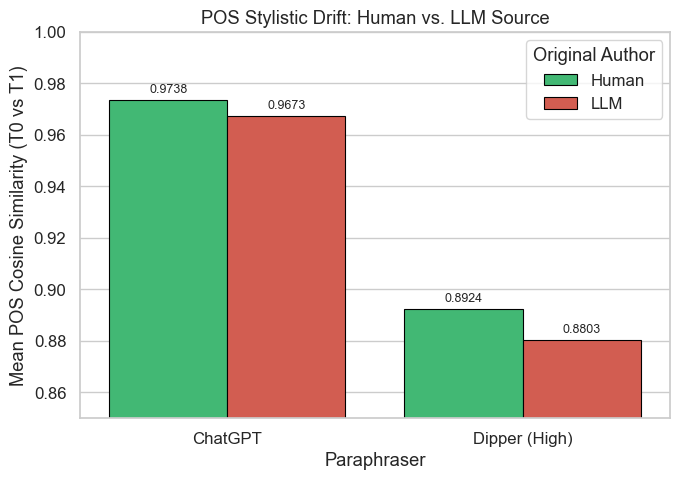

In [8]:
paired["source_group"] = paired["source"].apply(
    lambda s: "Human" if s == "Human" else "LLM"
)

# Per-dataset, per-source-group means
group_rows = []
for ds in ALL_DATASETS:
    for sg in ["Human", "LLM"]:
        mask = (paired["dataset"] == ds) & (paired["source_group"] == sg)
        sub = paired.loc[mask]
        group_rows.append({
            "dataset": ds,
            "source_group": sg,
            "cos_chatgpt": sub["cos_chatgpt"].mean(),
            "cos_dipper_high": sub["cos_dipper_high"].mean(),
        })

group_df = pd.DataFrame(group_rows)

# Aggregate across datasets (equal weight per dataset)
agg = group_df.groupby("source_group")[["cos_chatgpt", "cos_dipper_high"]].mean()
print("Aggregated POS cosine similarity by source group:\n")
print(agg.round(4).to_string())

# Reshape for chart
chart_data = agg.reset_index().melt(
    id_vars="source_group",
    value_vars=["cos_chatgpt", "cos_dipper_high"],
    var_name="paraphraser",
    value_name="cosine_similarity",
)
chart_data["paraphraser"] = chart_data["paraphraser"].map({
    "cos_chatgpt": "ChatGPT",
    "cos_dipper_high": "Dipper (High)",
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=chart_data, x="paraphraser", y="cosine_similarity",
    hue="source_group", palette={"Human": "#2ecc71", "LLM": "#e74c3c"},
    ax=ax, edgecolor="black", linewidth=0.8,
)
ax.set_xlabel("Paraphraser")
ax.set_ylabel("Mean POS Cosine Similarity (T0 vs T1)")
ax.set_title("POS Stylistic Drift: Human vs. LLM Source")
ax.set_ylim(0.85, 1.0)
ax.legend(title="Original Author")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "pos_human_vs_llm.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Per-dataset breakdown to check for domain effects
pd.set_option("display.float_format", "{:.4f}".format)
pivot = group_df.pivot(index="dataset", columns="source_group", values=["cos_chatgpt", "cos_dipper_high"])
print("Per-dataset POS cosine by source group:\n")
pivot.round(4)

Per-dataset POS cosine by source group:



cos_chatgpt        cos_dipper_high       
source_group       Human    LLM           Human    LLM
dataset                                               
cmv               0.9782 0.9702          0.9475 0.9070
eli5              0.9627 0.9590          0.9011 0.8816
sci_gen           0.9888 0.9744          0.8465 0.8549
tldr              0.9745 0.9740          0.8367 0.8582
wp                0.9820 0.9609          0.9591 0.9240
xsum              0.9764 0.9708          0.8852 0.8558
yelp              0.9538 0.9620          0.8705 0.8808

**2c Analysis:**

Contrary to initial expectations, Human-authored texts show *slightly less* POS drift than LLM-authored texts for both paraphrasers (Human: 0.9738 chatgpt / 0.8924 dipper vs. LLM: 0.9673 / 0.8803). The effect is modest but consistent across most datasets, with exceptions in yelp (chatgpt) and sci_gen, tldr (dipper), where the pattern reverses.

One explanation is that human writing follows conventional syntactic patterns : standard subject-verb-object constructions, predictable determiner and preposition usage : that paraphrasers naturally reproduce. LLM-generated T0 text, while broadly conforming to an "AI style," actually encompasses six distinct model signatures (OpenAI, PaLM, LLaMA, GLM, BLOOM, GPT-NeoX), each with subtle POS biases. When a single paraphraser rewrites these heterogeneous LLM outputs, it normalises them toward its own syntactic template, producing slightly larger POS shifts. The domain-level inconsistencies (e.g., sci_gen reversing the pattern for dipper) suggest that domain-specific vocabulary and syntax modulate this effect.

---
## Task 4 : The Paraphraser Fingerprint Report

### Question 1 : Which paraphraser causes the highest POS drift?

**Q1 Answer:**

Dipper (High) causes substantially higher POS drift than ChatGPT across all seven datasets. Overall, Dipper (High) achieves a mean POS cosine similarity of **0.8802 +/- 0.0917**, compared to ChatGPT's **0.9678 +/- 0.0436** : a gap of roughly 0.088. This ranking is consistent across every domain: even in wp, where Dipper performs best (0.9300), it still falls below ChatGPT's worst result (yelp, 0.9608).

The gap is most pronounced in **sci_gen** (chatgpt=0.9768, dipper=0.8535, delta=0.123) and **tldr** (0.9741 vs. 0.8548), both technical/scientific domains where Dipper's aggressive lexical and syntactic rewriting dismantles specialised sentence structures. In contrast, **wp** (creative writing) shows the smallest gap (0.9645 vs. 0.9300, delta=0.035), suggesting Dipper preserves literary syntax better. The Human vs. LLM split holds the same ranking: Dipper always drifts more than ChatGPT regardless of original author.

### Question 3 : Dipper intensity: does turning up the dial affect style and content equally?

In [ ]:
# Q3 supporting data : POS drift by Dipper intensity
q3_rows = []
for label, col in [("dipper_low", "cos_dipper_low"), ("dipper_high", "cos_dipper_high")]:
    vals = paired[col].dropna()
    q3_rows.append({
        "intensity": label,
        "mean_cos": vals.mean(),
        "std_cos": vals.std(),
        "n": len(vals),
    })

q3_table = pd.DataFrame(q3_rows).set_index("intensity")
q3_table["delta_from_low"] = q3_table["mean_cos"] - q3_table.loc["dipper_low", "mean_cos"]
print("POS cosine similarity by Dipper intensity:\n")
q3_table.round(4)

POS cosine similarity by Dipper intensity:



,mean_cos,std_cos,n,delta_from_low
intensity,,,,
dipper_low,0.9841,0.0304,19182,0.0000
dipper_high,0.8802,0.0917,19181,-0.1038


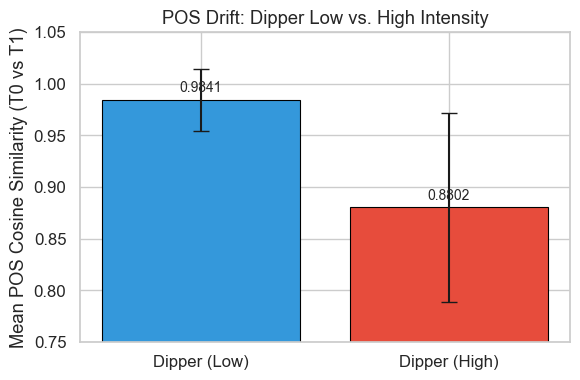

In [11]:
# Visualise the intensity comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Dipper (Low)", "Dipper (High)"],
    [q3_table.loc["dipper_low", "mean_cos"], q3_table.loc["dipper_high", "mean_cos"]],
    yerr=[q3_table.loc["dipper_low", "std_cos"], q3_table.loc["dipper_high", "std_cos"]],
    color=["#3498db", "#e74c3c"], edgecolor="black", linewidth=0.8, capsize=6,
)
ax.set_ylabel("Mean POS Cosine Similarity (T0 vs T1)")
ax.set_title("POS Drift: Dipper Low vs. High Intensity")
ax.set_ylim(0.75, 1.05)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "pos_dipper_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

**Q3 Answer (POS side):**

Increasing Dipper's intensity from low to high causes a dramatic rise in POS drift. Dipper (Low) preserves syntactic style almost perfectly (cosine = **0.9841 +/- 0.0304**), while Dipper (High) drops to **0.8802 +/- 0.0917** : a delta of **0.104**. This 10-point cosine gap indicates that the "high" setting aggressively restructures sentence syntax, redistributing POS proportions across UPOS categories. In contrast, "low" paraphrasing largely substitutes lexical items within existing syntactic frames, keeping the POS profile nearly identical to the original.

The variability also triples (std from 0.030 to 0.092), meaning some articles resist high-intensity restructuring while others are heavily transformed. The POS evidence alone suggests that turning up Dipper's dial does **not** affect style and content equally : style (POS) is disproportionately disrupted.


---
## Task 3 : NER Stability: Content Erasure

Named entities (PERSON, ORG, GPE, DATE, ...) are the semantic "planks" of a document. This task measures how many survive paraphrasing, distinguishing **dropping** (Recall) from **hallucination** (Precision).

### 3a. NER extraction

Extract lowercased named-entity sets for `text_T0`, `text_chatgpt`, `text_dipper_high`, `text_pegasus_slight`, `text_pegasus_full`, and `text_dipper_low` (needed for Q3).

In [12]:
import pickle
from src.features.ner import extract_ner_sets, entity_metrics

NER_COLS = [
    "text_T0", "text_chatgpt", "text_dipper_high",
    "text_pegasus_slight", "text_pegasus_full", "text_dipper_low",
]
NER_CACHE = DATA_PROCESSED / "ner_sets.pkl"

if NER_CACHE.exists():
    print(f"Loading cached NER sets from {NER_CACHE}")
    with open(NER_CACHE, "rb") as f:
        ner_sets = pickle.load(f)
else:
    ner_sets = {}
    for col in NER_COLS:
        print(f"\nExtracting NER for {col} ({len(paired)} texts)...")
        ner_sets[col] = extract_ner_sets(
            paired[col].tolist(), model_name=SPACY_MODEL, batch_size=500
        )

    with open(NER_CACHE, "wb") as f:
        pickle.dump(ner_sets, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"\nCached NER sets to {NER_CACHE}")

for col in NER_COLS:
    non_empty = sum(1 for s in ner_sets[col] if len(s) > 0)
    total_ents = sum(len(s) for s in ner_sets[col])
    print(f"  {col}: {non_empty}/{len(ner_sets[col])} texts with entities, "
          f"{total_ents} total entity mentions")

Loading cached NER sets from C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP\data\processed\ner_sets.pkl


  text_T0: 17543/19182 texts with entities, 184452 total entity mentions
  text_chatgpt: 17044/19182 texts with entities, 134210 total entity mentions
  text_dipper_high: 16454/19182 texts with entities, 95800 total entity mentions
  text_pegasus_slight: 17336/19182 texts with entities, 168300 total entity mentions
  text_pegasus_full: 16488/19182 texts with entities, 114801 total entity mentions
  text_dipper_low: 17308/19182 texts with entities, 158267 total entity mentions


In [13]:
# Quick sanity check: show entity sets for first 3 rows
for i in range(3):
    print(f"\nRow {i}  (dataset={paired.iloc[i]['dataset']}, source={paired.iloc[i]['source']}):")
    for col in ["text_T0", "text_chatgpt", "text_dipper_high"]:
        ents = ner_sets[col][i]
        display_ents = sorted(ents)[:8]
        suffix = f"  ... (+{len(ents)-8} more)" if len(ents) > 8 else ""
        print(f"  {col}: {display_ents}{suffix}")


Row 0  (dataset=cmv, source=BigScience):
  text_T0: ['0', '10', '16', '2.', '3', '8', '9', 'abstractbutton']  ... (+31 more)
  text_chatgpt: ['0', '10', '8', '9', 'abstractbutton', 'access control list', 'ai', 'annotations']  ... (+31 more)
  text_dipper_high: ['africa', 'african', 'asia', 'cadboro', 'central and south asia', 'europe', 'european', 'four']  ... (+14 more)

Row 1  (dataset=cmv, source=Eleuther-AI):
  text_T0: ['cmv', 'no exercise group', 'table 1: non-exercisers', 'two']
  text_chatgpt: ['0.01', 'average exercisers', 'gender', 'table 1', 'two']
  text_dipper_high: ['these quarters']

Row 2  (dataset=cmv, source=Human):
  text_T0: ['1.', '150', '2.', '3', '4.', '7 minutes', 'cmv', 'first']  ... (+12 more)
  text_chatgpt: ['150', '7 minutes', 'cmv', 'firstly', 'isis', 'islamic', 'nsa', "rand paul's"]  ... (+6 more)
  text_dipper_high: ['48', 'evening', 'pazhuvettarayar', 'pazhuvettarayars', 'pazhuvoor', 'that day', 'vandiyathevan']


### 3b. Entity retention metrics

For each article and each paraphraser, compute:
- **Jaccard**: overall entity-set overlap
- **Recall** (Retention): fraction of T0 entities kept in T1 (low = dropping)
- **Precision** (Fidelity): fraction of T1 entities that existed in T0 (low = hallucination)

Articles with zero T0 entities â†’ all metrics NaN (excluded from means).

In [ ]:
NER_PARAPHRASERS = {
    "chatgpt":         "text_chatgpt",
    "dipper_high":     "text_dipper_high",
    "pegasus_slight":  "text_pegasus_slight",
    "pegasus_full":    "text_pegasus_full",
    "dipper_low":      "text_dipper_low",
}

for label, col in NER_PARAPHRASERS.items():
    jaccards, recalls, precisions = [], [], []
    for i in range(len(paired)):
        j, r, p = entity_metrics(ner_sets["text_T0"][i], ner_sets[col][i])
        jaccards.append(j)
        recalls.append(r)
        precisions.append(p)
    paired[f"ner_jaccard_{label}"] = jaccards
    paired[f"ner_recall_{label}"] = recalls
    paired[f"ner_precision_{label}"] = precisions

# Report zero-entity exclusions
zero_t0 = sum(1 for s in ner_sets["text_T0"] if len(s) == 0)
total = len(paired)
print(f"Articles with zero T0 entities (excluded from means): "
      f"{zero_t0} / {total} ({zero_t0/total*100:.1f}%)\n")

# Summary table: mean ± std for chatgpt, dipper_high, pegasus_slight
report_labels = ["chatgpt", "dipper_high", "pegasus_slight"]
rows = []
for label in report_labels:
    row = {"paraphraser": label}
    for metric in ["jaccard", "recall", "precision"]:
        vals = paired[f"ner_{metric}_{label}"].dropna()
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"] = vals.std()
    rows.append(row)

metrics_table = pd.DataFrame(rows).set_index("paraphraser")

display_metrics = pd.DataFrame(index=metrics_table.index)
for metric in ["jaccard", "recall", "precision"]:
    display_metrics[metric] = metrics_table.apply(
        lambda r: f"{r[f'{metric}_mean']:.4f} ± {r[f'{metric}_std']:.4f}", axis=1
    )

print("NER entity metrics (T0 vs T1) : mean ± std:\n")
display_metrics

Articles with zero T0 entities (excluded from means): 1639 / 19182 (8.5%)

NER entity metrics (T0 vs T1) â€” mean ± std:



,jaccard,recall,precision
paraphraser,,,
chatgpt,0.5489 ± 0.3022,0.6255 ± 0.3059,0.7646 ± 0.2557
dipper_high,0.0227 ± 0.0662,0.0403 ± 0.1171,0.0624 ± 0.1483
pegasus_slight,0.8688 ± 0.2012,0.8880 ± 0.1902,0.9670 ± 0.0980


In [15]:
# Per-dataset breakdown
for label in report_labels:
    print(f"\n=== {label} ===")
    for ds in ALL_DATASETS:
        mask = paired["dataset"] == ds
        j = paired.loc[mask, f"ner_jaccard_{label}"].dropna()
        r = paired.loc[mask, f"ner_recall_{label}"].dropna()
        p = paired.loc[mask, f"ner_precision_{label}"].dropna()
        print(f"  {ds:10s}  J={j.mean():.4f}±{j.std():.4f}  "
              f"R={r.mean():.4f}±{r.std():.4f}  "
              f"P={p.mean():.4f}±{p.std():.4f}  (n={len(j)})")


=== chatgpt ===
  cmv         J=0.4784±0.3096  R=0.5478±0.3201  P=0.7128±0.2939  (n=1469)
  eli5        J=0.4677±0.3340  R=0.5310±0.3471  P=0.7210±0.3082  (n=2556)
  sci_gen     J=0.5829±0.3534  R=0.6329±0.3571  P=0.8403±0.2352  (n=2488)
  tldr        J=0.6255±0.2608  R=0.7071±0.2498  P=0.8092±0.2077  (n=2349)
  wp          J=0.5214±0.2914  R=0.6036±0.2974  P=0.7396±0.2601  (n=2533)
  xsum        J=0.6118±0.2130  R=0.7017±0.2043  P=0.8021±0.1656  (n=3185)
  yelp        J=0.5208±0.3120  R=0.6112±0.3156  P=0.7046±0.2888  (n=2963)

=== dipper_high ===
  cmv         J=0.0297±0.0637  R=0.0568±0.1326  P=0.0739±0.1505  (n=1469)
  eli5        J=0.0278±0.0830  R=0.0520±0.1453  P=0.0662±0.1561  (n=2556)
  sci_gen     J=0.0185±0.0531  R=0.0348±0.1110  P=0.0557±0.1357  (n=2488)
  tldr        J=0.0078±0.0309  R=0.0128±0.0568  P=0.0288±0.1015  (n=2349)
  wp          J=0.0529±0.1006  R=0.0926±0.1681  P=0.1178±0.1956  (n=2533)
  xsum        J=0.0101±0.0279  R=0.0140±0.0438  P=0.0515±0.1323  (n=3185)


### 3c. Pegasus(slight) vs. Pegasus(full): controlled experiment

Same model, same random seed, different coverage (25% vs 100% of sentences).
Grouped bar chart: three metric clusters, two bars each.

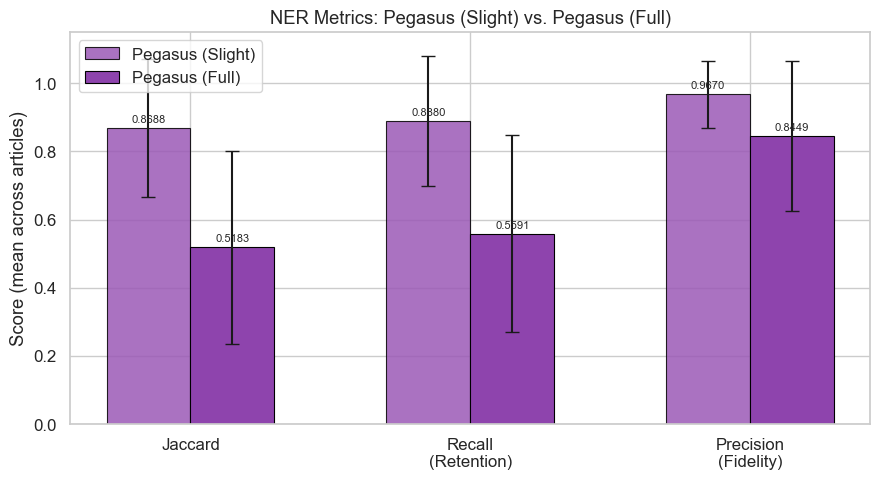

In [16]:
pegasus_variants = ["pegasus_slight", "pegasus_full"]
metrics_list = ["jaccard", "recall", "precision"]
metric_labels = {"jaccard": "Jaccard", "recall": "Recall\n(Retention)", "precision": "Precision\n(Fidelity)"}

chart_rows = []
for variant in pegasus_variants:
    for metric in metrics_list:
        vals = paired[f"ner_{metric}_{variant}"].dropna()
        chart_rows.append({
            "variant": "Pegasus (Slight)" if variant == "pegasus_slight" else "Pegasus (Full)",
            "metric": metric_labels[metric],
            "value": vals.mean(),
            "std": vals.std(),
        })

peg_df = pd.DataFrame(chart_rows)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics_list))
width = 0.3
colors = {"Pegasus (Slight)": "#9b59b6", "Pegasus (Full)": "#8e44ad"}

for i, variant in enumerate(["Pegasus (Slight)", "Pegasus (Full)"]):
    sub = peg_df[peg_df["variant"] == variant]
    bars = ax.bar(
        x + i * width - width / 2,
        sub["value"].values,
        width,
        yerr=sub["std"].values,
        label=variant,
        color=colors[variant],
        edgecolor="black",
        linewidth=0.8,
        capsize=5,
        alpha=0.85 + i * 0.15,
    )
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in metrics_list])
ax.set_ylabel("Score (mean across articles)")
ax.set_title("NER Metrics: Pegasus (Slight) vs. Pegasus (Full)")
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "ner_pegasus_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Per-dataset breakdown for cross-domain consistency check
print("Per-dataset Pegasus comparison:\n")
for ds in ALL_DATASETS:
    mask = paired["dataset"] == ds
    row_parts = [f"  {ds:10s}"]
    for variant in pegasus_variants:
        for metric in metrics_list:
            val = paired.loc[mask, f"ner_{metric}_{variant}"].dropna()
            row_parts.append(f"{metric[0].upper()}={val.mean():.3f}")
        row_parts.append(" | ")
    print("  ".join(row_parts))

Per-dataset Pegasus comparison:

  cmv         J=0.885  R=0.901  P=0.972   |   J=0.547  R=0.586  P=0.862   | 
  eli5        J=0.866  R=0.887  P=0.966   |   J=0.510  R=0.548  P=0.839   | 
  sci_gen     J=0.876  R=0.893  P=0.973   |   J=0.467  R=0.500  P=0.839   | 
  tldr        J=0.867  R=0.885  P=0.968   |   J=0.511  R=0.549  P=0.847   | 
  wp          J=0.884  R=0.908  P=0.965   |   J=0.550  R=0.603  P=0.838   | 
  xsum        J=0.838  R=0.857  P=0.961   |   J=0.520  R=0.558  P=0.858   | 
  yelp        J=0.879  R=0.897  P=0.968   |   J=0.533  R=0.576  P=0.835   | 


**3c Analysis (80-120 words):**

The difference between Pegasus (Slight) and Pegasus (Full) is substantially larger for Recall (entity dropping) than for Precision (hallucination). Recall drops by **0.329** (Slight: 0.8880, Full: 0.5591), while Precision drops by only **0.122** (Slight: 0.9670, Full: 0.8449). This indicates that moving from 25% to 100% sentence coverage primarily causes more original entities to be *lost*, rather than introducing spurious new ones. Even Full paraphrasing rarely hallucates entities (Precision remains above 0.84).

This pattern is consistent across all 7 datasets: the Recall gap ranges from 0.298 (xsum) to 0.393 (sci_gen), while the Precision gap stays narrow (0.103 to 0.134). Scientific text (sci_gen) shows the largest Recall drop, likely because specialised named entities are harder to preserve under full-coverage paraphrasing.

### Question 2 : Dropping vs. hallucination: which paraphraser is the worst offender for each?

In [ ]:
# Q2 supporting data: Recall and Precision for the three primary paraphrasers
q2_labels = ["chatgpt", "dipper_high", "pegasus_slight"]
q2_rows = []
for label in q2_labels:
    r = paired[f"ner_recall_{label}"].dropna()
    p = paired[f"ner_precision_{label}"].dropna()
    q2_rows.append({
        "paraphraser": label,
        "recall_mean": r.mean(), "recall_std": r.std(),
        "precision_mean": p.mean(), "precision_std": p.std(),
    })

q2_table = pd.DataFrame(q2_rows).set_index("paraphraser")

display_q2 = pd.DataFrame(index=q2_table.index)
display_q2["Recall (Retention)"] = q2_table.apply(
    lambda r: f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}", axis=1)
display_q2["Precision (Fidelity)"] = q2_table.apply(
    lambda r: f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}", axis=1)

print("Q2 Data : Recall (dropping) and Precision (hallucination):\n")
display_q2

Q2 Data â€” Recall (dropping) and Precision (hallucination):



,Recall (Retention),Precision (Fidelity)
paraphraser,,
chatgpt,0.6255 ± 0.3059,0.7646 ± 0.2557
dipper_high,0.0403 ± 0.1171,0.0624 ± 0.1483
pegasus_slight,0.8880 ± 0.1902,0.9670 ± 0.0980


**Q2 Answer (80-120 words):**

Dipper (High) is the worst offender for both entity dropping and hallucination, but by a dramatic margin. Its Recall is only **0.0403 +/- 0.1171**, meaning it drops over 95% of original entities which is far below ChatGPT (0.6255) and Pegasus Slight (0.8880). Its Precision is equally catastrophic at **0.0624 +/- 0.1483**, indicating that the few entities it does produce are overwhelmingly hallucinated.

Among the more conservative paraphrasers, ChatGPT shows lower Recall (0.6255) than Pegasus Slight (0.8880), making it the more aggressive entity dropper. However, ChatGPT also has lower Precision (0.7646 vs. 0.9670), suggesting it introduces more novel entities. Pegasus Slight preserves entities most faithfully on both axes, consistent with its minimal 25% sentence coverage.

In [ ]:
# Q3 supporting data : NER side: Entity Recall by Dipper intensity
q3_ner_rows = []
for label in ["dipper_low", "dipper_high"]:
    r = paired[f"ner_recall_{label}"].dropna()
    q3_ner_rows.append({
        "intensity": label,
        "recall_mean": r.mean(),
        "recall_std": r.std(),
        "n": len(r),
    })

q3_ner_table = pd.DataFrame(q3_ner_rows).set_index("intensity")
q3_ner_table["delta_from_low"] = q3_ner_table["recall_mean"] - q3_ner_table.loc["dipper_low", "recall_mean"]
print("NER Entity Recall by Dipper intensity:\n")
q3_ner_table.round(4)

NER Entity Recall by Dipper intensity:



,recall_mean,recall_std,n,delta_from_low
intensity,,,,
dipper_low,0.6497,0.2808,17543,0.0000
dipper_high,0.0403,0.1171,17543,-0.6094


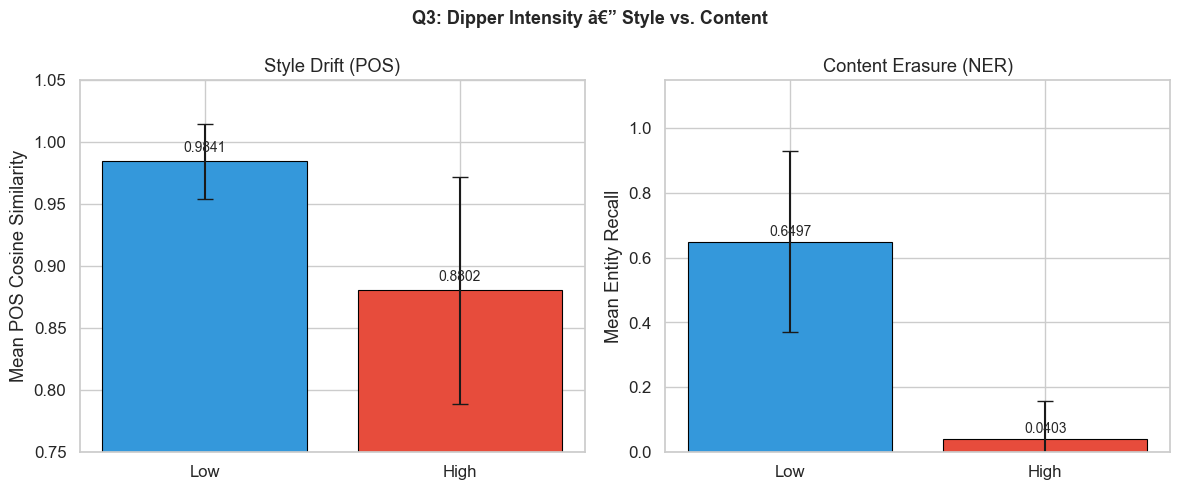

In [ ]:
# Combined Q3 chart: POS cosine and NER Recall side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: POS cosine
vals_pos = [q3_table.loc["dipper_low", "mean_cos"], q3_table.loc["dipper_high", "mean_cos"]]
errs_pos = [q3_table.loc["dipper_low", "std_cos"], q3_table.loc["dipper_high", "std_cos"]]
bars_pos = axes[0].bar(
    ["Low", "High"], vals_pos, yerr=errs_pos,
    color=["#3498db", "#e74c3c"], edgecolor="black", linewidth=0.8, capsize=6,
)
axes[0].set_ylabel("Mean POS Cosine Similarity")
axes[0].set_title("Style Drift (POS)")
axes[0].set_ylim(0.75, 1.05)
for bar in bars_pos:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10)

# Right: NER Recall
vals_ner = [q3_ner_table.loc["dipper_low", "recall_mean"], q3_ner_table.loc["dipper_high", "recall_mean"]]
errs_ner = [q3_ner_table.loc["dipper_low", "recall_std"], q3_ner_table.loc["dipper_high", "recall_std"]]
bars_ner = axes[1].bar(
    ["Low", "High"], vals_ner, yerr=errs_ner,
    color=["#3498db", "#e74c3c"], edgecolor="black", linewidth=0.8, capsize=6,
)
axes[1].set_ylabel("Mean Entity Recall")
axes[1].set_title("Content Erasure (NER)")
axes[1].set_ylim(0, 1.15)
for bar in bars_ner:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Q3: Dipper Intensity : Style vs. Content", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "q3_dipper_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

**Q3 Complete Answer (80-120 words):**

Increasing Dipper's intensity from low to high affects content (NER) far more than style (POS). The POS cosine delta is **0.104** (Low: 0.9841, High: 0.8802), while the NER Recall delta is **0.609** (Low: 0.6497, High: 0.0403); nearly six times larger. High-intensity Dipper destroys over 95% of named entities while POS distributions, though shifted, remain recognisable (cosine > 0.88).

This directly addresses RQ1: content features (named entities) are more *sensitive* to paraphrase intensity than stylistic features (POS distributions). However, style drifts *first* even at low intensity (POS cosine drops to 0.984, noticeably below 1.0), while low-intensity content preservation remains moderate (Recall 0.65). The implication is that style erodes gradually while content collapses catastrophically once intensity crosses a threshold.